In [1]:
from google.colab import files
uploaded = files.upload()

Saving wine.csv to wine.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [3]:
df = pd.read_csv("wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


# Exploratory Data Analysis (EDA)

EDA helps understand the dataset structure,
feature distributions, and relationships between variables.

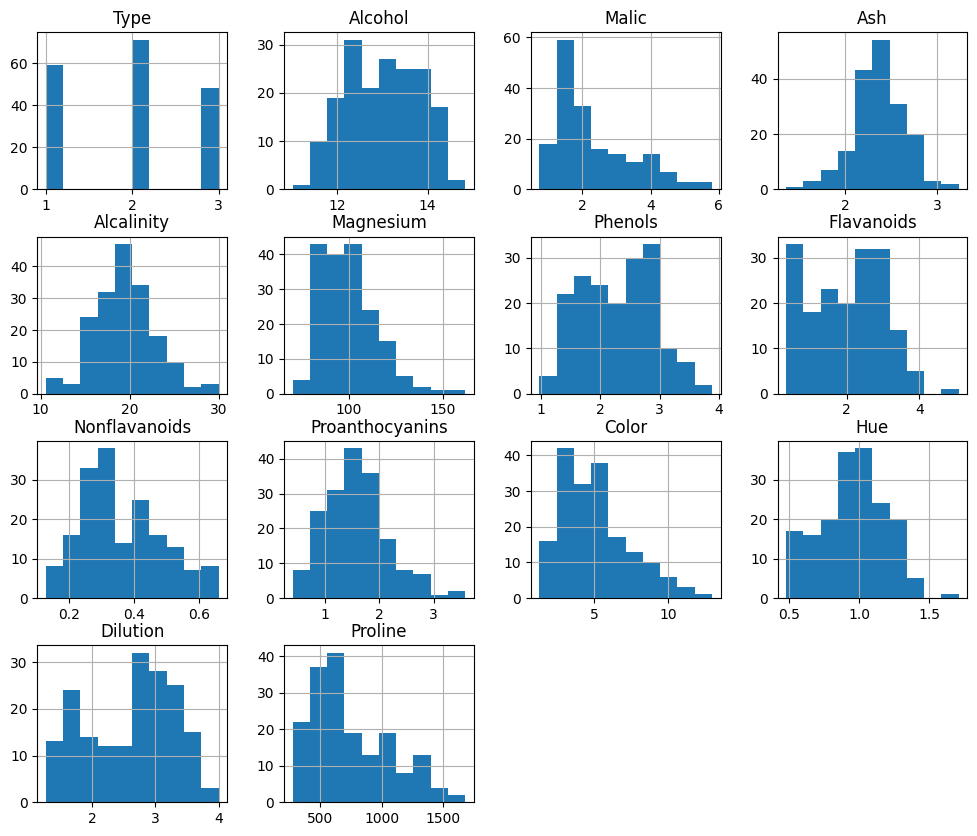

In [7]:
numeric_df = df.select_dtypes(include=['int64','float64'])

numeric_df.hist(figsize=(12,10))

plt.show()

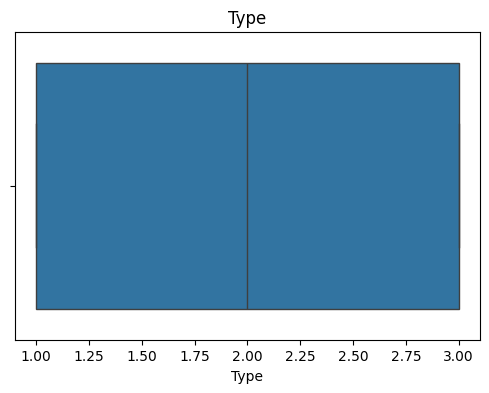

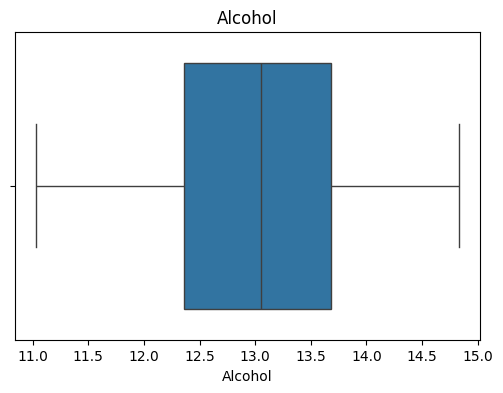

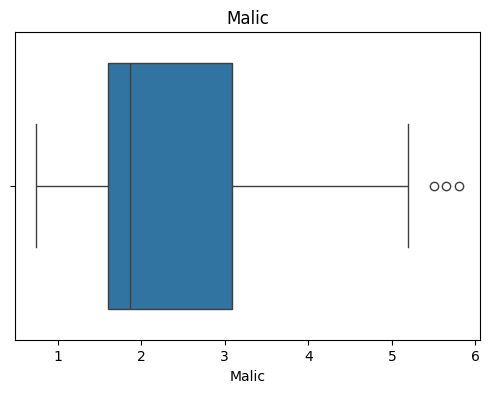

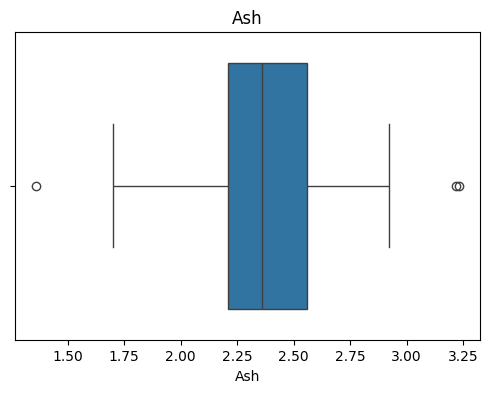

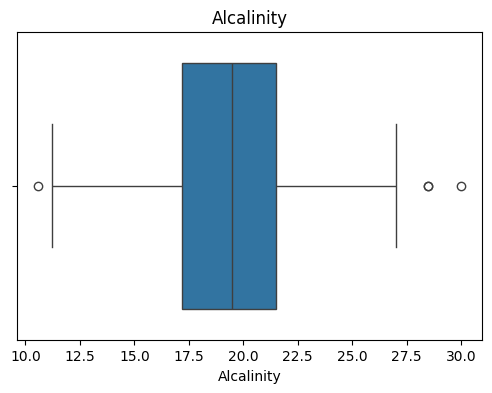

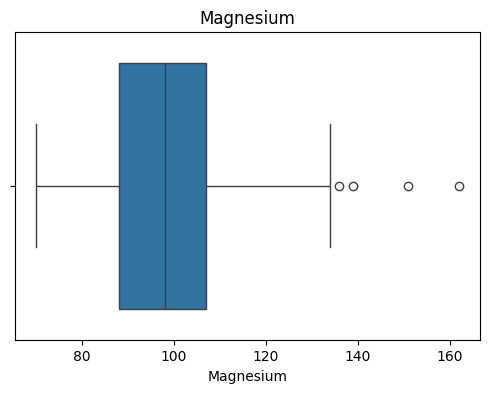

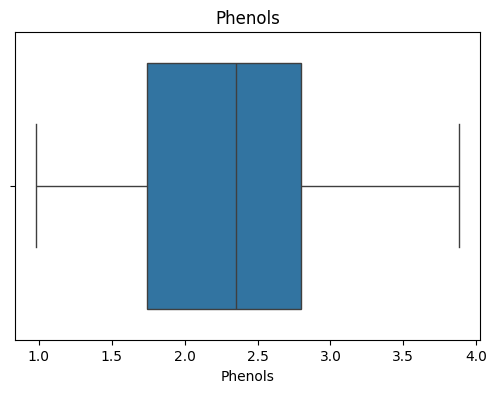

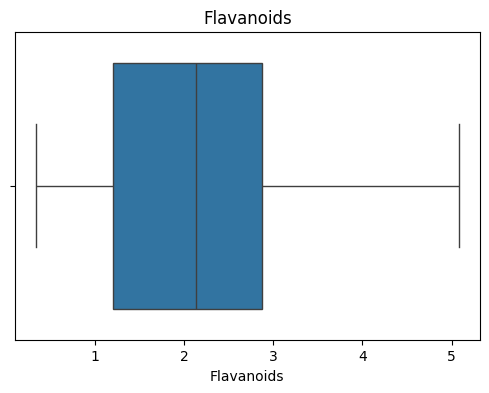

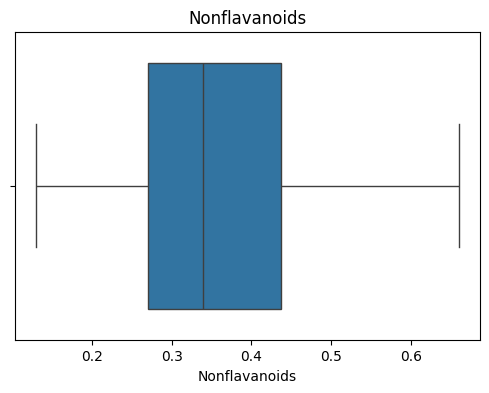

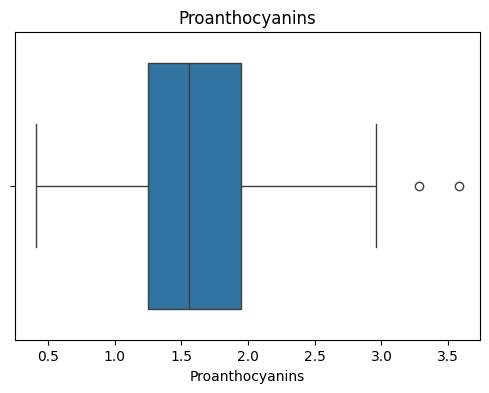

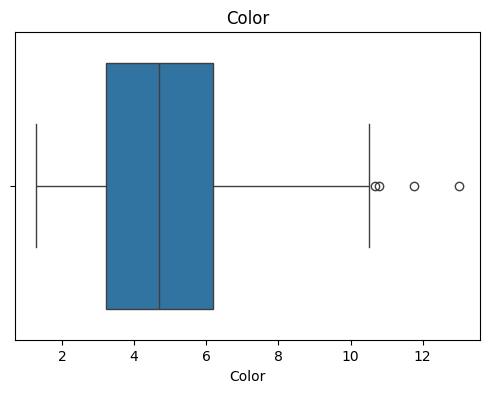

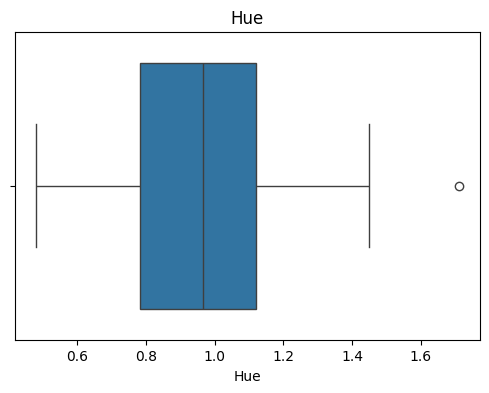

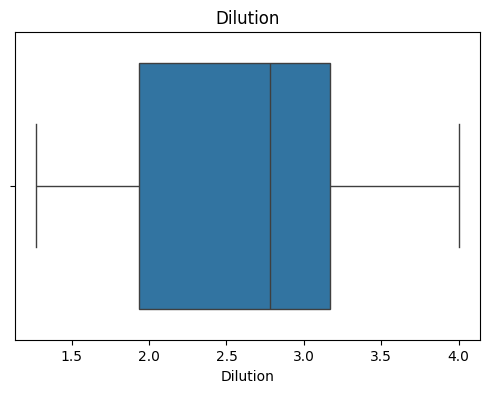

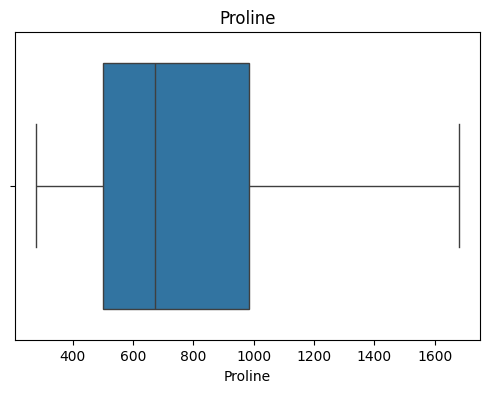

In [9]:
for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()


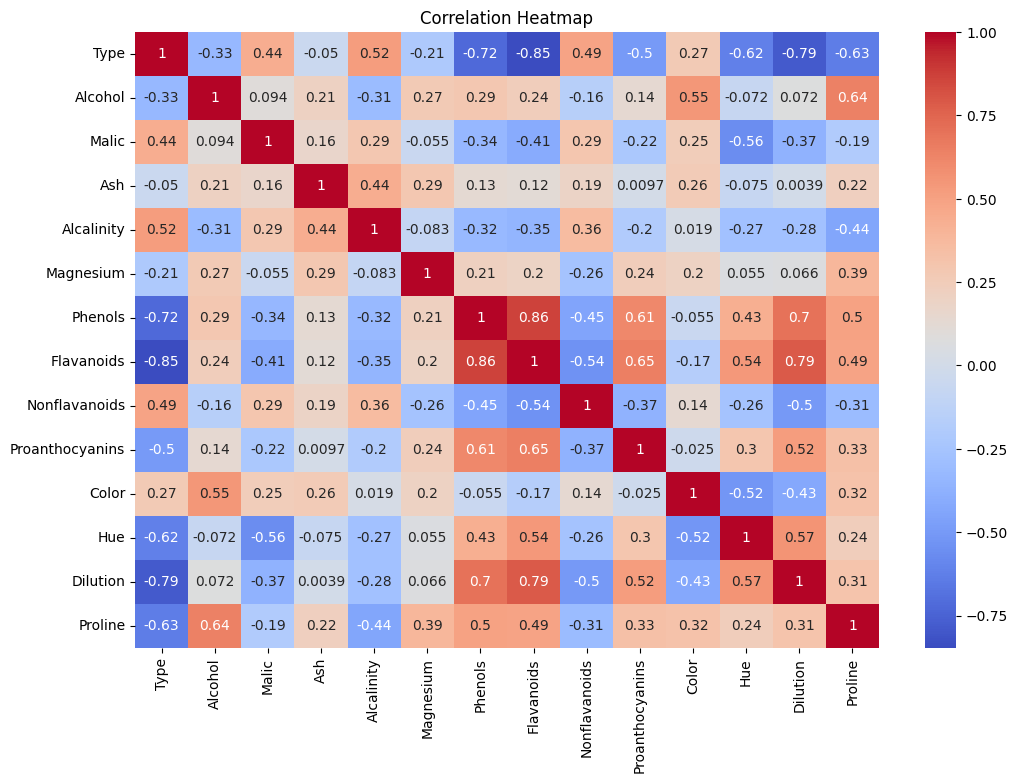

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


In [11]:
X = df.drop(df.columns[0], axis=1)


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData Standardized Successfully")


Data Standardized Successfully


In [13]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)


In [14]:
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio\n")

print(explained_variance)


Explained Variance Ratio

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


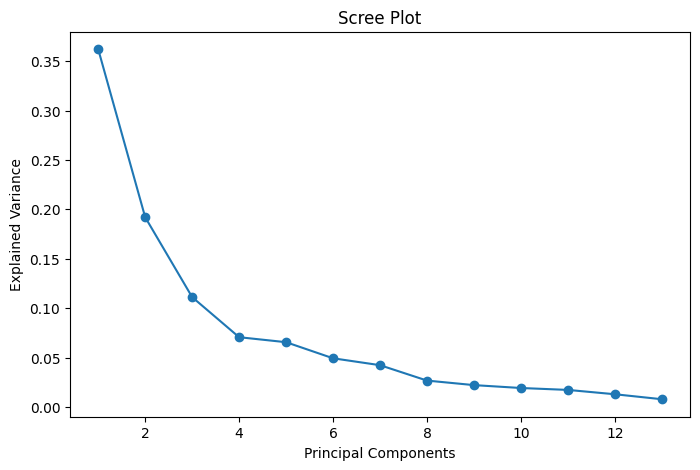

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Components")

plt.ylabel("Explained Variance")

plt.title("Scree Plot")

plt.show()


In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Shape\n")

print(X_pca.shape)


PCA Shape

(178, 2)


In [17]:
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_original.fit(X_scaled)

original_labels = kmeans_original.labels_

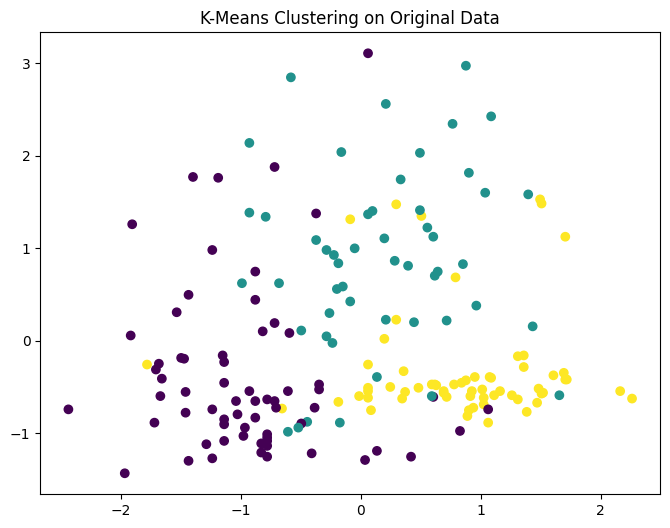

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=original_labels
)

plt.title("K-Means Clustering on Original Data")

plt.show()

In [19]:
sil_score_original = silhouette_score(
    X_scaled,
    original_labels
)

db_score_original = davies_bouldin_score(
    X_scaled,
    original_labels
)

print("\nOriginal Data Scores\n")

print("Silhouette Score:", sil_score_original)

print("Davies-Bouldin Score:", db_score_original)


Original Data Scores

Silhouette Score: 0.2848589191898987
Davies-Bouldin Score: 1.3891879777181648


In [20]:
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_pca.fit(X_pca)

pca_labels = kmeans_pca.labels_

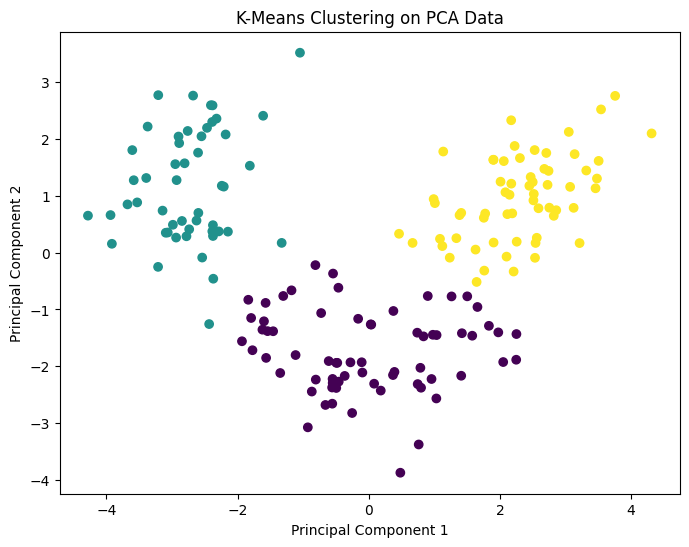

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=pca_labels
)

plt.title("K-Means Clustering on PCA Data")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [22]:
sil_score_pca = silhouette_score(
    X_pca,
    pca_labels
)

db_score_pca = davies_bouldin_score(
    X_pca,
    pca_labels
)

print("\nPCA Data Scores\n")

print("Silhouette Score:", sil_score_pca)

print("Davies-Bouldin Score:", db_score_pca)


PCA Data Scores

Silhouette Score: 0.5601697480957203
Davies-Bouldin Score: 0.5977226208167409


In [23]:
print("\nFINAL COMPARISON\n")

print("Original Data")

print("Silhouette Score:", sil_score_original)

print("Davies-Bouldin Score:", db_score_original)

print("\nPCA Data")

print("Silhouette Score:", sil_score_pca)

print("Davies-Bouldin Score:", db_score_pca)


FINAL COMPARISON

Original Data
Silhouette Score: 0.2848589191898987
Davies-Bouldin Score: 1.3891879777181648

PCA Data
Silhouette Score: 0.5601697480957203
Davies-Bouldin Score: 0.5977226208167409


Conclusion


PCA successfully reduced the dimensionality
of the Wine dataset.

K-Means clustering was applied on both
original and PCA-transformed datasets.

PCA improved visualization and reduced
dataset complexity while preserving
important information.
